Text(0, 0.5, 'Frequency')

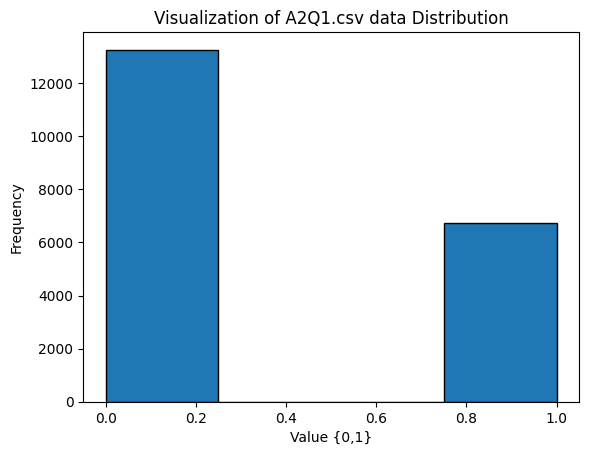

In [ ]:
# load the data from A2Q1.csv
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('A2Q1.csv', delimiter=',')
plt.hist(data.flatten(), bins= 4, edgecolor='black'); 

# visulalization on number of zeros and ones
plt.title('Visualization of A2Q1.csv data Distribution')
plt.xlabel('Value {0,1}')
plt.ylabel('Frequency')


In [ ]:
# helper functions

def bernoulli_prob(x, theta):
    """Calculates the probability of x for a multivariate Bernoulli distribution."""
    # Add a small epsilon to prevent log(0)
    epsilon = 1e-15
    theta = np.clip(theta, epsilon, 1 - epsilon)
    return np.prod(theta**x * (1 - theta)**(1 - x))

def calculate_log_likelihood(data, pi, theta):
    """Calculates the total log-likelihood of the data."""
    log_likelihood = 0
    for n in range(data.shape[0]):
        likelihood_n = 0
        for k in range(len(pi)):
            # Calculate probability of data point n given cluster k
            prob_n_k = 1.0
            for d in range(data.shape[1]):
                 prob_n_k *= (theta[k, d]**data[n, d]) * ((1 - theta[k, d])**(1 - data[n, d]))
            likelihood_n += pi[k] * prob_n_k
        log_likelihood += np.log(likelihood_n)
    return log_likelihood


def em_bernoulli_mixture(data, K, max_iters=100):
    """
    Performs EM for a Bernoulli Mixture Model.

    Args:
        data (np.array): The dataset (N x D).
        K (int): Number of mixture components.
        max_iters (int): Maximum number of iterations.

    Returns:
        tuple: (log_likelihoods, final_pi, final_theta)
    """
    N, D = data.shape

    # 1. Initialize parameters randomly
    pi = np.random.rand(K)
    pi /= pi.sum()
    theta = np.random.rand(K, D)

    log_likelihoods = []

    for i in range(max_iters):
        # --- E-Step ---
        gamma = np.zeros((N, K))
        for n in range(N):
            denominator = 0
            # Calculate likelihood for each cluster
            likelihoods_k = np.array([bernoulli_prob(data[n], theta[k]) for k in range(K)])
            
            # Calculate denominator for gamma
            denominator = np.dot(pi, likelihoods_k)
            
            # Calculate gamma (responsibilities)
            if denominator == 0: # Avoid division by zero
                # If a point is equally unlikely under all components,assign equal responsibilities.
                gamma[n, :] = 1.0 / K
            else:
                gamma[n, :] = (pi * likelihoods_k) / denominator


        # --- M-Step ---
        # Update pi
        Nk = gamma.sum(axis=0)
        pi = Nk / N

        # Update theta
        for k in range(K):
            if Nk[k] == 0: # Avoid division by zero if a cluster is empty
                theta[k, :] = np.random.rand(D) # Re-initialize empty cluster
            else:
                theta[k, :] = np.dot(gamma[:, k], data) / Nk[k]
        
        # Calculate and store log-likelihood
        log_likelihoods.append(calculate_log_likelihood(data, pi, theta))

    return log_likelihoods, pi, theta



In [ ]:
# ---Execution for Bernouli EM---

# Parameters
K = 4
num_initializations = 100
num_iterations = 20 # Increased for better convergence view

# Store log-likelihoods for all runs
all_log_likelihoods = np.zeros((num_initializations, num_iterations))

print("Running EM algorithm for 100 random initializations...")
for i in range(num_initializations):
    # Run EM
    log_likelihoods, _, _ = em_bernoulli_mixture(data, K, max_iters=num_iterations)
    all_log_likelihoods[i, :] = log_likelihoods
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1}/{num_initializations} initializations.")

# Average the log-likelihoods over all initializations
average_log_likelihood = all_log_likelihoods.mean(axis=0)


Running EM algorithm for 100 random initializations...
Completed 10/100 initializations.
Completed 20/100 initializations.
Completed 30/100 initializations.
Completed 40/100 initializations.
Completed 50/100 initializations.
Completed 60/100 initializations.
Completed 70/100 initializations.
Completed 80/100 initializations.
Completed 90/100 initializations.
Completed 100/100 initializations.


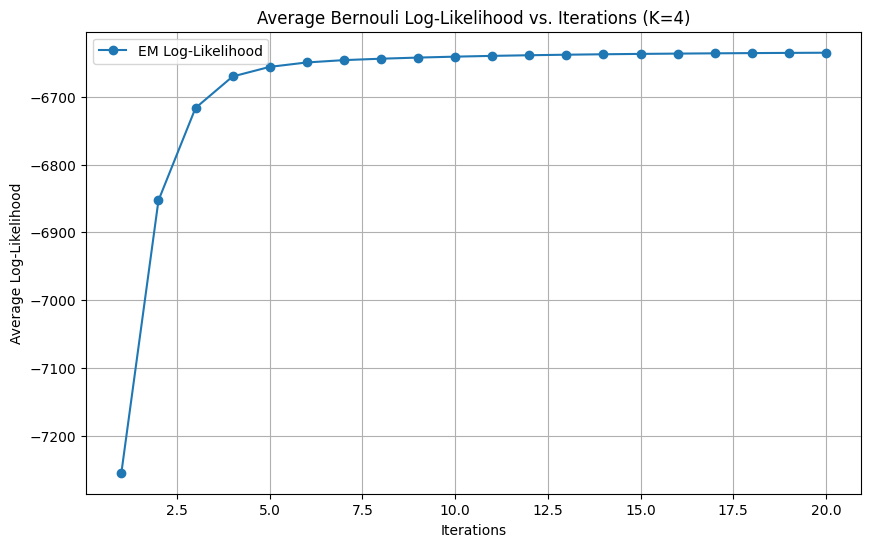

In [ ]:

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_iterations + 1), average_log_likelihood, marker='o', linestyle='-', label ='EM Log-Likelihood')
plt.title('Average Bernouli Log-Likelihood vs. Iterations (K=4)')
plt.xlabel('Iterations')
plt.ylabel('Average Log-Likelihood')
plt.grid(True)
# plt.show()
plt.legend()
plt.savefig('EM_Bernoulli_LogLikelihood.png')

In [ ]:
# implement the classic GMM 
from scipy.stats import multivariate_normal

def em_gaussian_mixture(data, K, max_iters= 20, tolerance=1e-4):
    """
    Performs EM for a Gaussian Mixture Model (GMM).
    """
    N, D = data.shape
    
    # 1. Initialize parameters
    # Initialize means by picking K random data points
    random_indices = np.random.choice(N, K, replace=False)
    mu = data[random_indices]
    
    # Initialize covariances as identity matrices
    sigma = [np.eye(D) for _ in range(K)]
    
    # Initialize mixing coefficients uniformly
    pi = np.full(K, 1.0 / K)
    
    log_likelihoods = []
    
    # Add a small regularization value to the diagonal of covariance matrices
    # to prevent singularity, which is likely due to binary data.
    regularization = 1e-6 

    for i in range(max_iters):
        # --- E-Step ---
        gamma = np.zeros((N, K))
        
        for k in range(K):
            try:
                # Calculate probability density for each point for cluster k
                gamma[:, k] = pi[k] * multivariate_normal.pdf(data, mean=mu[k], cov=sigma[k], allow_singular=True)
            except np.linalg.LinAlgError:
                # Handle singular covariance matrix if it still occurs
                sigma[k] += np.eye(D) * regularization
                gamma[:, k] = pi[k] * multivariate_normal.pdf(data, mean=mu[k], cov=sigma[k], allow_singular=True)

        # Calculate sum of probabilities for normalization
        gamma_sum = np.sum(gamma, axis=1, keepdims=True)
        
        # Avoid division by zero for points with zero probability under all components
        gamma_sum[gamma_sum == 0] = 1.0 
        
        # Normalize to get responsibilities
        gamma = gamma / gamma_sum
        
        # Calculate log-likelihood
        log_likelihood = np.sum(np.log(gamma_sum))
        log_likelihoods.append(log_likelihood)
        
        # Check for convergence
        if i > 0 and np.abs(log_likelihood - log_likelihoods[-2]) < tolerance:
            break
            
        # --- M-Step ---
        Nk = np.sum(gamma, axis=0)
        
        for k in range(K):
            if Nk[k] == 0:
                # Re-initialize empty cluster
                mu[k] = data[np.random.choice(N)]
                sigma[k] = np.eye(D)
                pi[k] = 1.0 / K
                continue
                
            # Update pi
            pi[k] = Nk[k] / N
            
            # Update mu
            mu[k] = np.dot(gamma[:, k], data) / Nk[k]
            
            # Update sigma
            diff = data - mu[k]
            sigma_k = np.dot((gamma[:, k] * diff.T), diff) / Nk[k]
            # Add regularization to prevent singularity
            sigma[k] = sigma_k + np.eye(D) * regularization
            
    return log_likelihoods


In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_iterations + 1), average_log_likelihood, marker='o', linestyle='-')
plt.title('Bernouli Average Log-Likelihood vs. Iterations (K=4)')
plt.xlabel('Iterations')
plt.ylabel('Average Log-Likelihood')
plt.grid(True)
plt.show()

Running EM for GMM (100 initializations)...
Completed 10/100 GMM initializations.
Completed 20/100 GMM initializations.
Completed 30/100 GMM initializations.
Completed 40/100 GMM initializations.
Completed 50/100 GMM initializations.
Completed 60/100 GMM initializations.
Completed 70/100 GMM initializations.
Completed 80/100 GMM initializations.
Completed 90/100 GMM initializations.
Completed 100/100 GMM initializations.
Saved GMM log-likelihood plot to gmm_log_likelihood.png


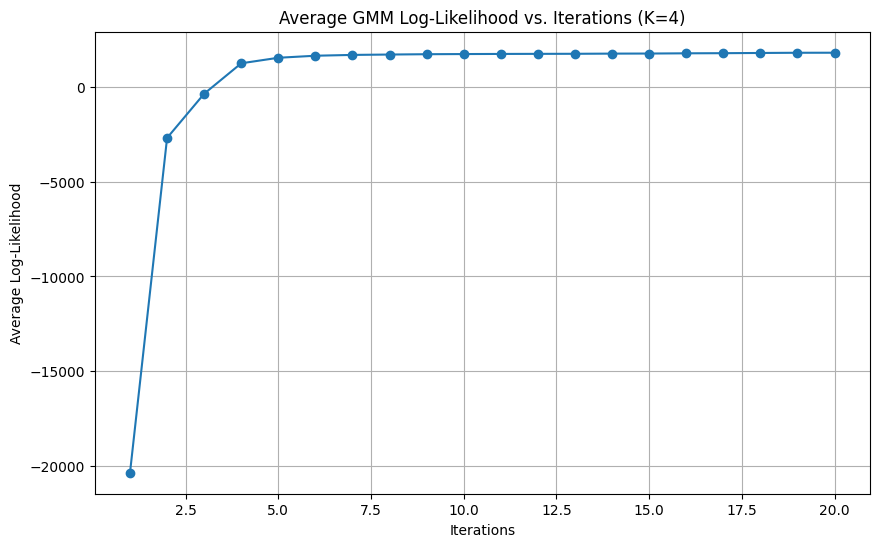

In [ ]:
# Parameters
K = 4
num_initializations = 100
num_iterations = 20

# --- Run GMM ---
print("Running EM for GMM (100 initializations)...")
all_gmm_log_likelihoods = []
max_len_gmm = 0 # To handle runs converging at different times

for i in range(num_initializations):
    log_likelihoods = em_gaussian_mixture(data, K, max_iters=num_iterations)
    all_gmm_log_likelihoods.append(log_likelihoods)
    if len(log_likelihoods) > max_len_gmm:
        max_len_gmm = len(log_likelihoods)
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1}/{num_initializations} GMM initializations.")

# Pad shorter runs with their final value to average correctly
avg_gmm_ll = np.zeros(max_len_gmm)
for ll in all_gmm_log_likelihoods:
    padded_ll = np.pad(ll, (0, max_len_gmm - len(ll)), 'edge')
    avg_gmm_ll += padded_ll

avg_gmm_ll /= num_initializations





Saved GMM log-likelihood plot to gmm_log_likelihood.png


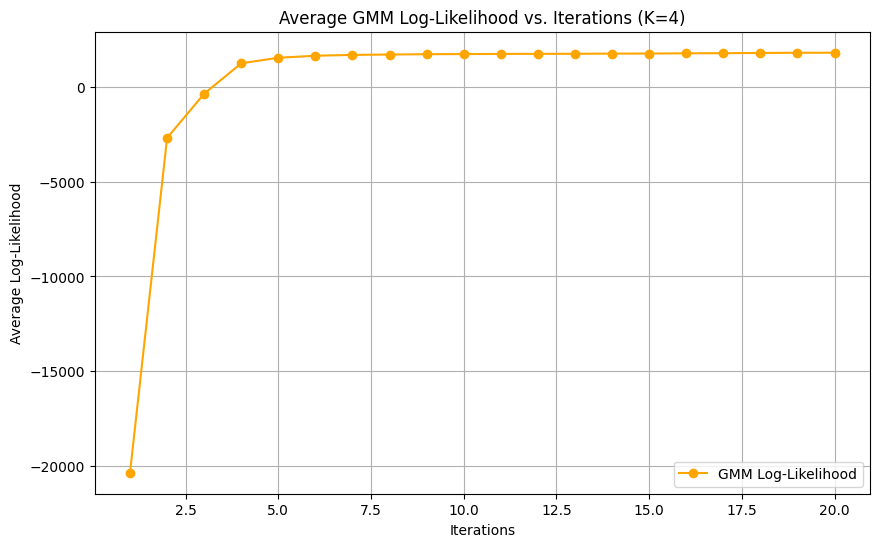

In [19]:
# --- Plotting ---

# Plot 1: GMM Log-Likelihood
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_len_gmm + 1), avg_gmm_ll, marker='o', linestyle='-', c = 'orange', label ='GMM Log-Likelihood')
plt.title('Average GMM Log-Likelihood vs. Iterations (K=4)')
plt.xlabel('Iterations')
plt.ylabel('Average Log-Likelihood')
plt.legend()
plt.grid(True)
plt.savefig('gmm_log_likelihood.png')
print("Saved GMM log-likelihood plot to gmm_log_likelihood.png")

In [ ]:

# --- Part 1(iii): K-Means Clustering ---

# Using the class structure from the previous assignment 
class KMeans:
    """K-means clustering implementation from scratch."""
    def __init__(self, k=4, max_iters=20, random_state=None):
        self.k = k
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.error_history = []

    def _initialize_centroids(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        random_idx = np.random.permutation(X.shape[0])
        self.centroids = X[random_idx[:self.k]]

    def _assign_clusters(self, X):
        distances = np.zeros((X.shape[0], self.k))
        for i in range(self.k):
            # Calculate Euclidean distance
            distances[:, i] = np.linalg.norm(X - self.centroids[i], axis=1)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centroids[i] = np.mean(cluster_points, axis=0)
        return new_centroids
        
    def _compute_error(self, X, labels):
        """Computes the Within-Cluster Sum of Squares (WCSS)"""
        error = 0
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                # Sum of squared distances to the centroid
                error += np.sum((cluster_points - self.centroids[i])**2)
        return error

    def fit(self, X):
        self.error_history = []
        self._initialize_centroids(X)
        
        for i in range(self.max_iters):
            labels = self._assign_clusters(X)
            
            # Store the error (WCSS) for this iteration
            self.error_history.append(self._compute_error(X, labels))
            
            new_centroids = self._update_centroids(X, labels)
            
            # Check for convergence
            if np.allclose(self.centroids, new_centroids):
                break
            
            self.centroids = new_centroids
        return self._assign_clusters(X)


Running K-Means (100 initializations)...
Completed 10/100 K-Means initializations.
Completed 20/100 K-Means initializations.
Completed 30/100 K-Means initializations.
Completed 40/100 K-Means initializations.
Completed 50/100 K-Means initializations.
Completed 60/100 K-Means initializations.
Completed 70/100 K-Means initializations.
Completed 80/100 K-Means initializations.
Completed 90/100 K-Means initializations.
Completed 100/100 K-Means initializations.
Saved K-Means objective plot to kmeans_objective.png


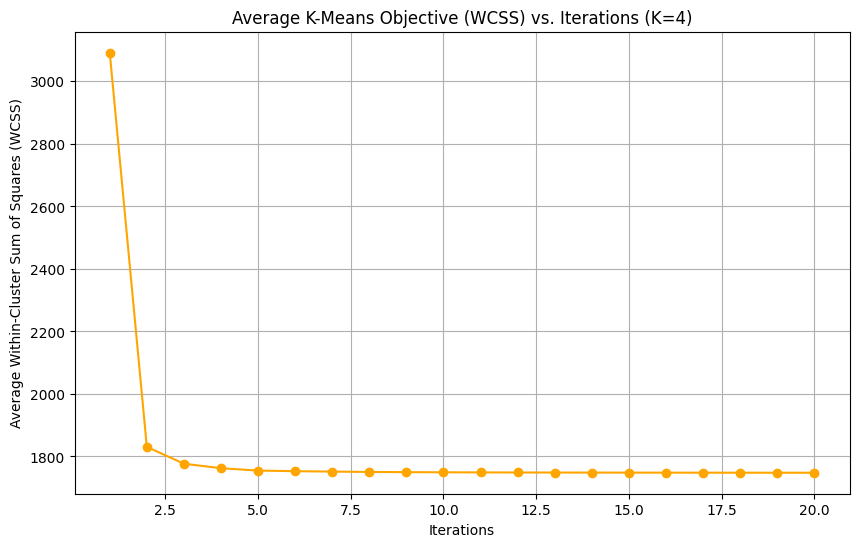

In [ ]:
# --- Run K-Means ---
print("\nRunning K-Means (100 initializations)...")
all_kmeans_errors = []
max_len_kmeans = 0 # To handle runs converging at different times

for i in range(num_initializations):
    kmeans = KMeans(k=K, max_iters=num_iterations, random_state= i)
    kmeans.fit(data)
    all_kmeans_errors.append(kmeans.error_history)
    if len(kmeans.error_history) > max_len_kmeans:
        max_len_kmeans = len(kmeans.error_history)
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1}/{num_initializations} K-Means initializations.")

# Pad shorter runs with their final value to average correctly
avg_kmeans_error = np.zeros(max_len_kmeans)
for error_hist in all_kmeans_errors:
    padded_error = np.pad(error_hist, (0, max_len_kmeans - len(error_hist)), 'edge')
    avg_kmeans_error += padded_error
    
avg_kmeans_error /= num_initializations



Saved K-Means objective plot to kmeans_objective.png


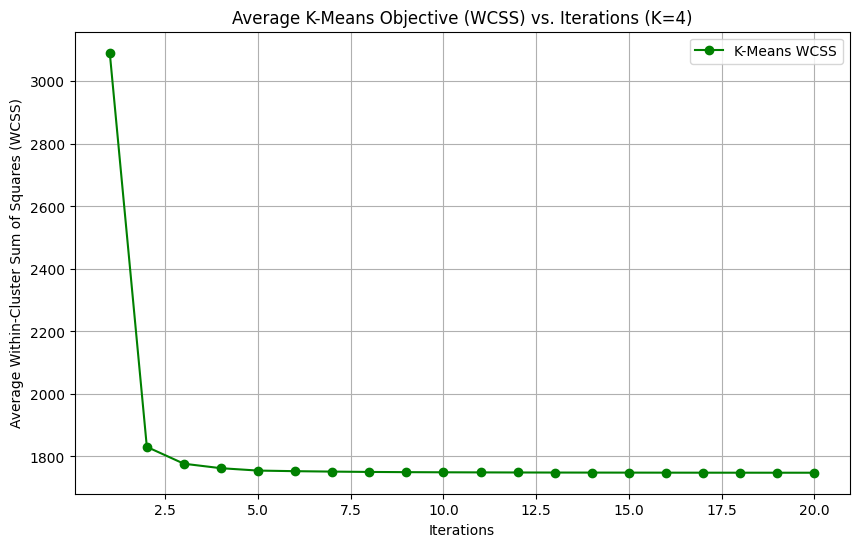

In [20]:

# Plot 2: K-Means Objective (WCSS)
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_len_kmeans + 1), avg_kmeans_error, marker='o', linestyle='-', color='green', label ='K-Means WCSS')
plt.title('Average K-Means Objective (WCSS) vs. Iterations (K=4)')
plt.xlabel('Iterations')
plt.ylabel('Average Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.legend()
plt.savefig('kmeans_objective.png')
print("Saved K-Means objective plot to kmeans_objective.png")